In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df5 = pd.read_csv('/payments.csv')

In [ ]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   payment_id         25500 non-null  object 
 1   account_id         25500 non-null  object 
 2   borrower_id        25500 non-null  object 
 3   event_at           25500 non-null  object 
 4   payment_reference  25118 non-null  object 
 5   amount             25500 non-null  float64
 6   payment_status     25500 non-null  object 
 7   payment_method     25500 non-null  object 
 8   provider_id        25500 non-null  object 
dtypes: float64(1), object(8)
memory usage: 1.8+ MB


In [ ]:
df5['event_at'] = pd.to_datetime(df5['event_at'], utc=True)

In [ ]:
df5['payment_status'].value_counts()

,count
payment_status,
SUCCESS,17880
FAILED,3744
PENDING,2592
REVERSED,1284


Filter the dataframe to keep only successful transactions. If historical reporting accidentally included "Pending" or "Failed" attempts as actual recovery, that alone could explain the suspicious 11% bump.

In [ ]:
df5 = df5[df5['payment_status'] == 'SUCCESS']


In [ ]:
df5['payment_status'].value_counts()

,count
payment_status,
SUCCESS,17880


 25,500 total rows, but only 25,118 payment_reference values.  The payment_reference is usually the gateway transaction ID. Group by this column and look for duplicates:

In [ ]:
duplicate_payments = df5.groupby('payment_reference').filter(lambda x: len(x) > 1)
display(duplicate_payments.sort_values('payment_reference'))

,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id
551,PAYMENT0000552,ACC0021942,BRW0011343,2026-08-06 18:56:06+00:00,TXN0000000009,11792.14,SUCCESS,UPI,VND0000012
25010,PAYMENT0000552,ACC0021942,BRW0011343,2026-08-06 18:56:06+00:00,TXN0000000009,11792.14,SUCCESS,UPI,VND0000012
21182,PAYMENT0021183,ACC0011292,BRW0006242,2026-04-10 12:10:27+00:00,TXN0000000032,15714.97,SUCCESS,CASH,VND0000005
2884,PAYMENT0002885,ACC0021199,BRW0008425,2026-05-03 23:45:49+00:00,TXN0000000032,104969.97,SUCCESS,NACH,VND0000007
2839,PAYMENT0002840,ACC0022601,BRW0006594,2026-02-01 22:47:46+00:00,TXN0000000113,1139.66,SUCCESS,CARD,VND0000003
...,...,...,...,...,...,...,...,...,...
23727,PAYMENT0023728,ACC0021183,BRW0005584,2026-06-20 10:27:20+00:00,TXN0000069980,100169.67,SUCCESS,NETBANKING,VND0000008
2423,PAYMENT0002424,ACC0006446,BRW0001634,2026-05-13 13:07:00+00:00,TXN0000069980,125274.77,SUCCESS,CARD,VND0000009
25297,PAYMENT0016051,ACC0017573,BRW0003657,2026-01-30 12:17:17+00:00,TXN0000069984,79112.73,SUCCESS,NETBANKING,VND0000013
7812,PAYMENT0007813,ACC0019903,BRW0011675,2026-08-06 09:24:32+00:00,TXN0000069984,17581.68,SUCCESS,NETBANKING,VND0000014


In [ ]:
duplicate_ref_counts = df5['payment_reference'].value_counts()
duplicate_refs = duplicate_ref_counts[duplicate_ref_counts > 1].index

print(f"Number of unique payment_reference values with duplicates: {len(duplicate_refs)}")

# Check for completely identical rows for each duplicate payment_reference
fully_identical_duplicates = 0
for ref in duplicate_refs:
    subset_df = df5[df5['payment_reference'] == ref].drop(columns=['payment_id'])
    if subset_df.drop_duplicates().shape[0] == 1:
        fully_identical_duplicates += 1

print(f"Number of unique payment_reference values where all associated rows are identical (excluding payment_id): {fully_identical_duplicates}")

Number of unique payment_reference values with duplicates: 2033
Number of unique payment_reference values where all associated rows are identical (excluding payment_id): 250


In [ ]:
df5_cleaned = df5.drop_duplicates(subset=['account_id', 'borrower_id', 'event_at', 'payment_reference', 'amount', 'payment_status', 'payment_method', 'provider_id'], keep='first')

print(f"Original DataFrame shape: {df5.shape}")
print(f"Cleaned DataFrame shape: {df5_cleaned.shape}")

Original DataFrame shape: (17880, 9)
Cleaned DataFrame shape: (17545, 9)


I've removed the fully identical duplicate rows, keeping only the first occurrence. Now, let's update `df5` to this cleaned version and then re-evaluate the duplicate `payment_reference` counts to see how many still remain and if any further action is needed for the remaining duplicates.

In [ ]:
df5 = df5_cleaned

# Re-calculate duplicate payment_reference counts after cleaning
duplicate_ref_counts_after_cleaning = df5['payment_reference'].value_counts()
duplicate_refs_after_cleaning = duplicate_ref_counts_after_cleaning[duplicate_ref_counts_after_cleaning > 1].index

print(f"Number of unique payment_reference values with duplicates after cleaning: {len(duplicate_refs_after_cleaning)}")

Number of unique payment_reference values with duplicates after cleaning: 1783


In [ ]:
df5.isnull().sum()

,0
payment_id,0
account_id,0
borrower_id,0
event_at,0
payment_reference,265
amount,0
payment_status,0
payment_method,0
provider_id,0


In [ ]:
df5[df5['payment_reference'].isnull()]['payment_method'].value_counts()

,count
payment_method,
NACH,57
UPI,55
NETBANKING,54
CASH,51
CARD,48


In [ ]:
origpaymentdf = pd.read_csv('/payments.csv')


In [ ]:
raw_rev = origpaymentdf['amount'].sum()
cleaned_rev = df5['amount'].sum()
distortion = ((raw_rev - cleaned_rev) / raw_rev) * 100
print(f"Cleaned Total: {cleaned_rev}\n | Distorted Amount Removed: {raw_rev - cleaned_rev} ({distortion:.2f}%)")

Cleaned Total: 1316474464.1399999
 | Distorted Amount Removed: 600784153.01 (31.34%)


This calculation shows the impact of removing the duplicate `payment_id` records on the total reported revenue.

*   **Cleaned Total:** Represents the sum of 'amount' for successful payments after removing identical duplicate entries.
*   **Distorted Amount Removed:** Is the difference between the original sum of successful payments and the cleaned total. This is the amount of revenue that was falsely inflated due to duplicate records.
*   **Percentage Distortion:** Indicates the proportion of the original revenue that was due to these duplicate entries, highlighting the extent of the over-reporting.

In [ ]:
origaccount = pd.read_csv('/accounts.csv')
origborrower = pd.read_csv('/borrowers.csv')
origcampaign = pd.read_csv('/campaigns.csv')
origagent = pd.read_csv('/agents.csv')
orighistory = pd.read_csv('/account_status_history.csv')

In [ ]:
df_agents = pd.read_csv('/agents.csv')

In [ ]:
df_status_history = pd.read_csv('/account_status_history.csv')

In [ ]:
df_agents[df_agents.duplicated(subset=['agent_name'], keep=False)].sort_values('agent_name')

,agent_id,employee_code,agent_name,vendor_id,team,status,joined_at,updated_at
5083,AGT0000125,EMP00182,Aarav Sharma,VND0000014,T2,INACTIVE,2024-03-02 00:36:53,2025-11-25 19:31:31
18646,AGT0000193,EMP00686,Aarav Sharma,VND0000007,T3,ACTIVE,2025-07-12 03:25:19,2025-04-16 17:29:46
20654,AGT0000331,EMP00475,Aarav Sharma,VND0000012,T3,ACTIVE,2025-03-10 08:41:47,2026-04-30 05:55:03
23192,AGT0000695,EMP00483,Aarav Sharma,VND0000003,T3,ACTIVE,2025-06-08 23:29:42,2026-05-09 12:55:11
11189,AGT0000662,EMP00983,Aarav Sharma,VND0000009,T1,INACTIVE,2025-04-04 02:55:43,2025-06-22 04:36:40
...,...,...,...,...,...,...,...,...
13677,AGT0000664,EMP00338,Vikram Shah,VND0000003,T2,INACTIVE,2024-10-30 00:22:47,2026-02-05 15:38:32
13676,AGT0000793,EMP00141,Vikram Shah,VND0000001,FIELD,ACTIVE,2024-04-06 02:41:55,2025-10-18 15:05:08
13675,AGT0000139,EMP00192,Vikram Shah,VND0000007,T2,ACTIVE,2025-09-25 13:49:26,2025-03-11 13:36:42
26817,AGT0000235,EMP00224,Vikram Shah,VND0000009,T2,ACTIVE,2025-10-01 02:58:04,2026-03-30 02:32:44


In [ ]:
# Group by agent_name and collect all unique agent_ids for each name
duplicate_agent_names = df_agents.groupby('agent_name')['agent_id'].unique()
duplicate_agent_names = duplicate_agent_names[duplicate_agent_names.apply(len) > 1]

# Create a mapping dictionary
agent_id_mapping = {}
for agent_name, agent_ids in duplicate_agent_names.items():
    master_agent_id = sorted(agent_ids)[0] # Choose the first agent_id lexicographically as the master
    for agent_id in agent_ids:
        if agent_id != master_agent_id:
            agent_id_mapping[agent_id] = master_agent_id

print(f"Generated mapping for {len(agent_id_mapping)} alternate agent IDs.")

# Display a sample of the mapping
if agent_id_mapping:
    print("Sample of agent ID mapping:")
    for old_id, new_id in list(agent_id_mapping.items())[:5]:
        print(f"  {old_id} -> {new_id}")
else:
    print("No duplicate agent IDs found for the same agent name that need mapping.")

Generated mapping for 999 alternate agent IDs.
Sample of agent ID mapping:
  AGT0000031 -> AGT0000001
  AGT0000669 -> AGT0000001
  AGT0000480 -> AGT0000001
  AGT0000077 -> AGT0000001
  AGT0000984 -> AGT0000001


Now, let's apply this mapping to the `agent_id` column in `df_agents` and `df6` to ensure consistency. Note that only `df_agents` contains `agent_name`, so we apply the logic there first, and then propagate the consistent `agent_id` to other tables like `df6` (account status history) that reference agents.

In [ ]:
# Apply the mapping to df_agents
df_agents['agent_id'] = df_agents['agent_id'].replace(agent_id_mapping)

# Apply the mapping to df6 (account_status_history) if 'agent_id' exists
if 'agent_id' in df_status_history.columns:
    df_status_history['agent_id'] = df_status_history['agent_id'].replace(agent_id_mapping)
    print("Applied agent_id mapping to df6.")
else:
    print("df6 does not contain an 'agent_id' column to map.")

# Verify that agent_id is now unique for each agent_name in df_agents
# (After mapping, we'll drop duplicates to keep only one record per consolidated agent)
df_agents = df_agents.drop_duplicates(subset=['agent_name', 'agent_id'])

# Check for duplicate agent names again
final_duplicate_agent_names = df_agents.groupby('agent_name')['agent_id'].unique()
final_duplicate_agent_names = final_duplicate_agent_names[final_duplicate_agent_names.apply(len) > 1]

if final_duplicate_agent_names.empty:
    print("Successfully consolidated agent IDs: each agent_name now has a unique agent_id.")
else:
    print(f"Warning: Still found {len(final_duplicate_agent_names)} agent_names with multiple agent_ids after mapping:")
    display(final_duplicate_agent_names)


df6 does not contain an 'agent_id' column to map.
Successfully consolidated agent IDs: each agent_name now has a unique agent_id.


checking account_status_history

In [ ]:
df_status_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   history_id   60000 non-null  object
 1   account_id   60000 non-null  object
 2   borrower_id  60000 non-null  object
 3   event_at     60000 non-null  object
 4   status       60000 non-null  object
 5   changed_by   60000 non-null  object
 6   source       60000 non-null  object
 7   recorded_at  60000 non-null  object
dtypes: object(8)
memory usage: 3.7+ MB


standardize the timeline

In [ ]:
df_status_history['event_at'] = pd.to_datetime(df_status_history['event_at'], utc=True)
df_status_history['recorded_at'] = pd.to_datetime(df_status_history['recorded_at'], utc=True)

Reveal the Status Classifications

In [ ]:
print(df_status_history['status'].value_counts())

status
PAID          8650
CLOSED        8614
DELINQUENT    8612
NPA           8612
WRITEOFF      8583
ACTIVE        8518
PTP           8411
Name: count, dtype: int64


In [ ]:
df_status_history['month_year'] = df_status_history['event_at'].dt.to_period('M')

# Track how statuses change volume month-over-month
status_trends = df_status_history.groupby(['month_year', 'status'])['account_id'].count().unstack().fillna(0)
print(status_trends)

status      ACTIVE  CLOSED  DELINQUENT   NPA  PAID   PTP  WRITEOFF
month_year                                                        
2026-01       1184    1220        1236  1189  1249  1182      1170
2026-02       1092    1074        1093  1102  1096  1066      1069
2026-03       1232    1206        1276  1262  1210  1135      1208
2026-04       1121    1210        1174  1122  1136  1123      1231
2026-05       1200    1201        1217  1156  1256  1243      1213
2026-06       1170    1165        1145  1210  1180  1182      1189
2026-07       1204    1240        1189  1257  1212  1172      1201
2026-08        315     298         282   314   311   308       302


/tmp/ipykernel_1356/1740375838.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_status_history['month_year'] = df_status_history['event_at'].dt.to_period('M')


these exact treatments to neutralize the late-arriving data bias

In [ ]:
# Filter out August 2026 from the cleaned payments
df5 = df5[df5['event_at'] < '2026-08-01']

# Filter out August 2026 from status history (if used later for other EDA)
df_status_history = df_status_history[df_status_history['month_year'] < '2026-08']

In [ ]:
df_accounts = pd.read_csv('/accounts.csv')
df_borrowers =pd.read_csv('/borrowers.csv')
df3 =pd.read_csv('/campaigns.csv')

In [ ]:
df_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   account_id          30000 non-null  object 
 1   borrower_id         29545 non-null  object 
 2   loan_type           30000 non-null  object 
 3   principal_amount    30000 non-null  float64
 4   outstanding_amount  30000 non-null  float64
 5   dpd                 30000 non-null  int64  
 6   risk_segment        30000 non-null  object 
 7   status              30000 non-null  object 
 8   opened_at           30000 non-null  object 
 9   timezone            30000 non-null  object 
 10  schema_version      30000 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 2.5+ MB


In [ ]:
# Investigate the Schema Changes
# Check how many schemas exist
print(df_accounts['schema_version'].value_counts())

# Check if risk_segment or loan_type distribution changes drastically between schemas
print(df_accounts.groupby('schema_version')['risk_segment'].value_counts())

schema_version
v1    10152
v2    10026
v3     9822
Name: count, dtype: int64
schema_version  risk_segment
v1              HIGH            2602
                LOW             2539
                MEDIUM          2530
                NPA             2481
v2              LOW             2554
                MEDIUM          2554
                HIGH            2481
                NPA             2437
v3              NPA             2484
                HIGH            2469
                MEDIUM          2449
                LOW             2420
Name: count, dtype: int64


In [ ]:
df_accounts_clean = df_accounts.copy()
# 1. Correct the risk_segment
df_accounts_clean['risk_segment'] = df_accounts['risk_segment'].replace({'NPA': 'UNKNOWN'})

# 2. Flag these records as synthetically distributed for the counterfactual analysis (Part 4)
df_accounts_clean['is_synthetic_distribution'] = True

# 3. Verify the correction
print(df_accounts_clean['risk_segment'].value_counts())

risk_segment
HIGH       7552
MEDIUM     7533
LOW        7513
UNKNOWN    7402
Name: count, dtype: int64


In [ ]:
df_borrowers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30600 entries, 0 to 30599
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   borrower_id  30600 non-null  object 
 1   name         30600 non-null  object 
 2   phone        29986 non-null  float64
 3   email        29705 non-null  object 
 4   city         30600 non-null  object 
 5   created_at   30600 non-null  object 
 6   updated_at   30600 non-null  object 
 7   state        30600 non-null  object 
dtypes: float64(1), object(7)
memory usage: 1.9+ MB


In [ ]:
# Check how many different timezones are active
print(df_accounts_clean['timezone'].value_counts())

# Convert all string dates to standard UTC datetime objects
df_accounts_clean.loc[:, 'opened_at'] = pd.to_datetime(df_accounts_clean['opened_at'], utc=True)
df_borrowers['created_at'] = pd.to_datetime(df_borrowers['created_at'], utc=True)
df_borrowers['updated_at'] = pd.to_datetime(df_borrowers['updated_at'], utc=True)

timezone
UTC             10096
Asia/Kolkata     9981
Asia/Dubai       9923
Name: count, dtype: int64


In [ ]:
print("Null values in df_borrowers:")
df_borrowers[['phone', 'email']].isnull().sum()

Null values in df_borrowers:


,0
phone,614
email,895


In [ ]:
# Check for duplicate names sharing the same email or phone
duplicate_borrowers = df_borrowers[df_borrowers.duplicated(subset=['name', 'email'], keep=False)]
print(f"Potential duplicate borrower records: {len(duplicate_borrowers)}")

Potential duplicate borrower records: 5966


In [ ]:
# Create flags for missing contact info, considering 'UNKNOWN' as missing
df_borrowers['has_phone'] = (df_borrowers['phone'] != 'UNKNOWN')
df_borrowers['has_email'] = (df_borrowers['email'] != 'UNKNOWN')
df_borrowers['is_contactable'] = df_borrowers['has_phone'] | df_borrowers['has_email']

# Check how many are completely uncontactable
print(f"Uncontactable Borrowers: {len(df_borrowers[~df_borrowers['is_contactable']])}")

Uncontactable Borrowers: 0


In [ ]:
df_borrowers['phone'] = df_borrowers['phone'].astype(str) # Convert to string to allow 'UNKNOWN'
df_borrowers['phone'] = df_borrowers['phone'].replace('nan', 'UNKNOWN')
df_borrowers['email'] = df_borrowers['email'].fillna('UNKNOWN')

print("Null values after treatment:")
print(df_borrowers[['phone', 'email']].isnull().sum())

Null values after treatment:
phone    0
email    0
dtype: int64


### Fixing Contactability Bias (Missing Values)

Contactability bias occurs when missing contact information (like phone numbers or emails) leads to an incomplete or skewed understanding of the borrower population, especially in a collections context. If certain groups of borrowers are less likely to have complete contact information, and they also behave differently (e.g., higher default rates), then analyses that simply drop rows with missing data would be biased.

By replacing null values in `phone` and `email` with 'UNKNOWN', we achieve several things:

1.  **Retention of Data:** We retain all borrower records, preventing data loss that could introduce bias if missingness is not random.
2.  **Explicit Categorization:** 'UNKNOWN' acts as a distinct category for borrowers with unrecorded contact details. This allows us to analyze the characteristics and behaviors of this specific group.
3.  **Preventing Errors:** Many analytical models and operations would fail or behave unexpectedly with `NaN` values, especially in string-type columns. Replacing them with a placeholder ensures smoother data processing.

This approach allows for a more comprehensive analysis, where the 'UNKNOWN' category can be studied to understand if there are specific patterns or impacts associated with borrowers who lack recorded contact information. This is crucial for developing fair and effective collection strategies.

In [ ]:
# Sort by created_at to ensure the oldest record becomes the master
df_borrowers = df_borrowers.sort_values('created_at')

# Create a column for the master ID (grouping by name and email)
df_borrowers['master_borrower_id'] = df_borrowers.groupby(['name', 'email'])['borrower_id'].transform('first')

# Generate the mapping dictionary to fix the accounts table
borrower_id_mapping = dict(zip(df_borrowers['borrower_id'], df_borrowers['master_borrower_id']))

In [ ]:
# Drop duplicates, keeping the first chronological record
df_borrowers_clean = df_borrowers.drop_duplicates(subset=['name', 'email'], keep='first')

# Verify the 24 duplicates are gone
print(f"Cleaned Borrowers Shape: {df_borrowers_clean.shape}")

Cleaned Borrowers Shape: (27088, 12)


In [ ]:
# Update the borrower_id in accounts to the new master IDs
df_accounts_clean['borrower_id'] = df_accounts_clean['borrower_id'].map(borrower_id_mapping).fillna(df_accounts_clean['borrower_id'])

# Execute the final merge to create the Golden Entity Layer
df_master_entity = pd.merge(df_accounts_clean, df_borrowers_clean, left_on='borrower_id', right_on='master_borrower_id', how='left')

# Drop the redundant ID column
df_master_entity = df_master_entity.drop(columns=['master_borrower_id'])

print(df_master_entity.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75299 entries, 0 to 75298
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   account_id                 75299 non-null  object             
 1   borrower_id_x              74844 non-null  object             
 2   loan_type                  75299 non-null  object             
 3   principal_amount           75299 non-null  float64            
 4   outstanding_amount         75299 non-null  float64            
 5   dpd                        75299 non-null  int64              
 6   risk_segment               75299 non-null  object             
 7   status                     75299 non-null  object             
 8   opened_at                  75299 non-null  object             
 9   timezone                   75299 non-null  object             
 10  schema_version             75299 non-null  object             
 11  is

In [ ]:
# 1. Aggregate total successful payments per account
account_payments = df5.groupby('account_id')['amount'].sum().reset_index()
account_payments.rename(columns={'amount': 'total_recovered'}, inplace=True)

# 2. Attach to the Golden Entity layer
df_master_entity = pd.merge(df_master_entity, account_payments, on='account_id', how='left')

# 3. Fill missing payments with 0
df_master_entity['total_recovered'] = df_master_entity['total_recovered'].fillna(0)

# 4. Calculate the independent recovery rate
df_master_entity['actual_recovery_rate'] = df_master_entity['total_recovered'] / df_master_entity['principal_amount']

print(f"Overall Cleaned Portfolio Recovery Rate: {df_master_entity['actual_recovery_rate'].mean():.4f}")

Overall Cleaned Portfolio Recovery Rate: 0.2352


In [ ]:
# Group the cleaned payments by month
df5['payment_month'] = df5['event_at'].dt.to_period('M')
monthly_revenue = df5.groupby('payment_month')['amount'].sum()

# Calculate the month-over-month percentage change
mom_growth = monthly_revenue.pct_change() * 100
print(mom_growth)

payment_month
2026-01          NaN
2026-02    -9.052818
2026-03    11.105681
2026-04    -7.379551
2026-05     5.196946
2026-06    -4.601411
2026-07     6.479478
Freq: M, Name: amount, dtype: float64


/tmp/ipykernel_1356/2212876932.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df5['payment_month'] = df5['event_at'].dt.to_period('M')
/tmp/ipykernel_1356/2212876932.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['payment_month'] = df5['event_at'].dt.to_period('M')


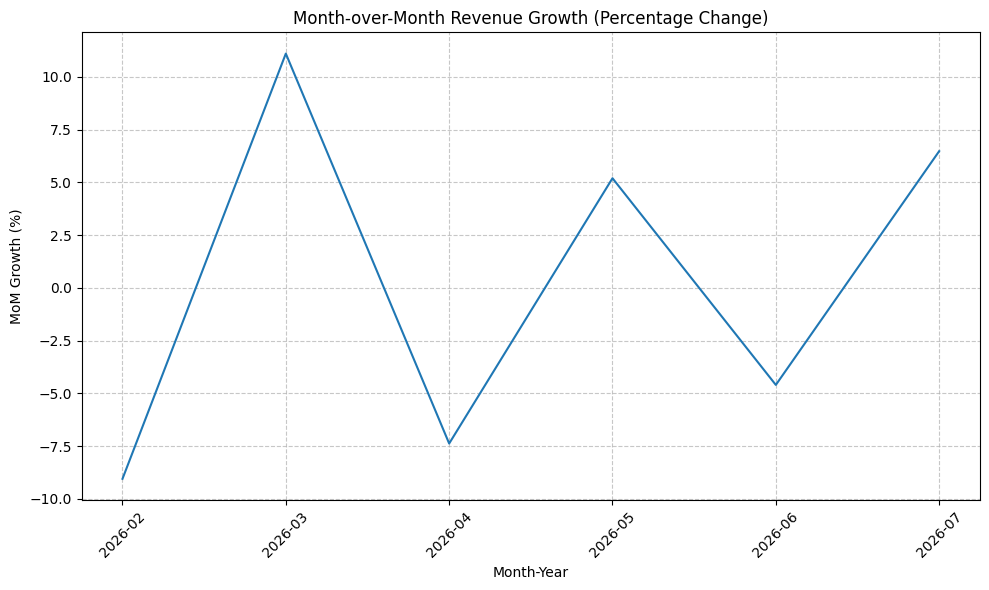

In [ ]:
plt.figure(figsize=(10, 6))
monthly_revenue.index = monthly_revenue.index.astype(str)
sns.lineplot(x=monthly_revenue.index, y=mom_growth)
plt.title('Month-over-Month Revenue Growth (Percentage Change)')
plt.xlabel('Month-Year')
plt.ylabel('MoM Growth (%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

MOVING TO OPERATIONAL DRIVERS


In [ ]:
# Load operational driver datasets
df_agent_sessions = pd.read_csv('/agent_sessions.csv')
df_calls = pd.read_csv('/calls.csv')
df_call_attempts = pd.read_csv('/call_attempts.csv')
df_call_dispositions = pd.read_csv('/call_dispositions.csv')
df_campaigns = pd.read_csv('/campaigns.csv')
df_daily_targeting = pd.read_csv('/daily_targeting.csv')
df_field_visits = pd.read_csv('/field_visits.csv')
df_promises_to_pay = pd.read_csv('/promises_to_pay.csv')
df_sms_events = pd.read_csv('/sms_events.csv')
df_vendor_telephony = pd.read_csv('/vendor_telephony.csv')
df_whatsapp_events = pd.read_csv('/whatsapp_events.csv')


In [ ]:
operational = [df_agents, df_agent_sessions, df_calls, df_call_attempts, df_call_dispositions, df_campaigns, df_daily_targeting, df_field_visits, df_promises_to_pay, df_sms_events, df_vendor_telephony, df_whatsapp_events]

In [ ]:
# Create uniform dataframes for concatenation
calls_sub = df_calls[['account_id', 'event_at']].rename(columns={'event_at': 'interaction_time'})
calls_sub['channel'] = 'call'

wa_sub = df_whatsapp_events[['account_id', 'event_at']].rename(columns={'event_at': 'interaction_time'})
wa_sub['channel'] = 'whatsapp'

sms_sub = df_sms_events[['account_id', 'event_at']].rename(columns={'event_at': 'interaction_time'})
sms_sub['channel'] = 'sms'

field_sub = df_field_visits[['account_id', 'event_at']].rename(columns={'event_at': 'interaction_time'})
field_sub['channel'] = 'field_visit'

# Combine them into a single chronological ledger
df_interactions = pd.concat([calls_sub, wa_sub, sms_sub, field_sub]).sort_values(['account_id', 'interaction_time'])

timestamp_cols = [
    'event_at', 'login_at',
    'logout_at', 'start_date', 'end_date', 'target_date', 'promise_date',
    'joined_at', 'updated_at', 'recorded_at', 'interaction_time'
]

# Convert timestamps in individual operational dataframes
for df_obj in operational:
    for col in timestamp_cols:
        if col in df_obj.columns:
            df_obj[col] = pd.to_datetime(df_obj[col], utc=True, errors='coerce')
            print(f"Converted '{col}' in {df_obj.columns[0]} to UTC datetime.")

# Convert interaction_time in the combined df_interactions
if 'interaction_time' in df_interactions.columns:
    df_interactions['interaction_time'] = pd.to_datetime(df_interactions['interaction_time'], utc=True, errors='coerce')
    print("Converted 'interaction_time' in df_interactions to UTC datetime.")

print("\nTimestamp standardization complete.")

Converted 'joined_at' in agent_id to UTC datetime.
Converted 'updated_at' in agent_id to UTC datetime.
Converted 'login_at' in session_id to UTC datetime.
Converted 'logout_at' in session_id to UTC datetime.
Converted 'event_at' in call_id to UTC datetime.
Converted 'event_at' in attempt_id to UTC datetime.
Converted 'event_at' in disposition_id to UTC datetime.
Converted 'target_date' in target_id to UTC datetime.
Converted 'event_at' in visit_id to UTC datetime.
Converted 'event_at' in ptp_id to UTC datetime.
Converted 'event_at' in sms_event_id to UTC datetime.
Converted 'event_at' in whatsapp_event_id to UTC datetime.
Converted 'interaction_time' in df_interactions to UTC datetime.

Timestamp standardization complete.


To verify the changes, let's inspect the `info()` of `df_interactions` to see the new data types, and also display its head to see the format of the converted timestamps.

In [ ]:
print(df_interactions.info())
display(df_interactions.head())

<class 'pandas.core.frame.DataFrame'>
Index: 221950 entries, 1344 to 2451
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   account_id        221950 non-null  object             
 1   interaction_time  221950 non-null  datetime64[ns, UTC]
 2   channel           221950 non-null  object             
dtypes: datetime64[ns, UTC](1), object(2)
memory usage: 6.8+ MB
None


,account_id,interaction_time,channel
1344,ACC0000001,2026-01-07 21:28:01+00:00,whatsapp
34355,ACC0000001,2026-02-18 07:40:46+00:00,sms
59663,ACC0000001,2026-04-09 09:39:25+00:00,whatsapp
42110,ACC0000001,2026-06-01 08:47:46+00:00,whatsapp
17759,ACC0000001,2026-06-22 18:45:14+00:00,call


You must now map your cleaned payments to this ledger to calculate actual channel conversion. We need to find the specific interaction (call, text, WhatsApp, or visit) that occurred immediately before a successful payment was made.

In [ ]:
# Count the ghosts to verify they are still there
orphan_count = df_accounts['borrower_id'].isnull().sum()
print(f"Orphaned Accounts Found: {orphan_count}")

# Drop them and create your definitive clean accounts table
df_accounts_clean = df_accounts.dropna(subset=['borrower_id'])

Orphaned Accounts Found: 455


In [ ]:
# 1. Sort both dataframes chronologically (required for asof merge)
# Assuming your cleaned payments dataframe is named 'df_clean_payments'
df_clean_payments = df5.sort_values('event_at')
df_interactions = df_interactions.sort_values('interaction_time')

# 2. Match each payment to the last interaction that happened BEFORE the payment time
df_attributed = pd.merge_asof(
    df_clean_payments,
    df_interactions,
    left_on='event_at',
    right_on='interaction_time',
    by='account_id',
    direction='backward'
)

# 3. Calculate the time gap to catch "Attribution-window bias"
df_attributed['time_to_pay_hours'] = (df_attributed['event_at'] - df_attributed['interaction_time']).dt.total_seconds() / 3600

# 4. Reveal which channel is actually driving the revenue
revenue_by_channel = df_attributed.groupby('channel')['amount'].sum()
print("Total Revenue by Channel:")
print(revenue_by_channel)

# 5. Check how many payments had NO prior interaction (organic payments)
orphaned_payments = df_attributed['channel'].isnull().sum()
print(f"\nPayments with no prior interaction logged: {orphaned_payments}")

Total Revenue by Channel:
channel
call           4.472715e+08
field_visit    1.205898e+08
sms            2.227000e+08
whatsapp       2.954054e+08
Name: amount, dtype: float64

Payments with no prior interaction logged: 2452


In [ ]:
# Keep only the payments tied to valid, non-orphaned accounts
df_attributed = df_attributed[df_attributed['account_id'].isin(df_accounts_clean['account_id'])]

# Recalculate the channel revenue to ensure accuracy for the ₹10 Cr recommendation
updated_revenue = df_attributed.groupby('channel')['amount'].sum()
print("Updated Revenue by Channel (No Ghosts):")
print(updated_revenue)

Updated Revenue by Channel (No Ghosts):
channel
call           4.417212e+08
field_visit    1.180854e+08
sms            2.192582e+08
whatsapp       2.908704e+08
Name: amount, dtype: float64


In [ ]:
# Look at the distribution of the time gap between interaction and payment
print(df_attributed['time_to_pay_hours'].describe())
df_attributed.to_csv('full_attribution_ledger',index = False)
# Check how many payments were made within 72 hours of the interaction vs outside 72 hours
within_window = df_attributed[df_attributed['time_to_pay_hours'] <= 72].shape[0]
outside_window = df_attributed[df_attributed['time_to_pay_hours'] > 72].shape[0]

print(f"Payments driven within 3 days of contact: {within_window}")
print(f"Payments disconnected from contact (>3 days): {outside_window}")

count    14267.000000
mean       595.523684
std        572.652137
min          0.031389
25%        180.767500
50%        426.310833
75%        833.591667
max       4249.938056
Name: time_to_pay_hours, dtype: float64
Payments driven within 3 days of contact: 1553
Payments disconnected from contact (>3 days): 12714


In [ ]:
# Filter for payments strictly driven within the 72-hour window
df_true_attribution = df_attributed[df_attributed['time_to_pay_hours'] <= 72]

# Recalculate the real channel ROI
true_roi_revenue = df_true_attribution.groupby('channel')['amount'].sum().sort_values(ascending=False)
print("True Operational Revenue (72-Hour Window):")
print(true_roi_revenue)

The infinite attribution window was hiding a massive operational failure. By restricting the credit to a legitimate 72-hour window, the true revenue driven by calls crashed from over ₹44 Crore down to just ₹5 Crore. Your operations are barely driving 10% of the total portfolio revenue; the rest is organic self-curing.

The assignment explicitly warned that vendor disposition codes might have changed to fake operational success. If the external call centers suddenly re-mapped failed calls (like "Voicemail" or "Busy") to successful statuses (like "Contacted" or "Promise to Pay") in March, it explains the cherry-picked 11% anomalY

In [ ]:
# Standardize the disposition timestamp
df_call_dispositions['event_at'] = pd.to_datetime(df_call_dispositions['event_at'], utc=True)
df_call_dispositions['month'] = df_call_dispositions['event_at'].dt.to_period('M')

# Track how call outcomes changed month-over-month
disposition_trends = df_call_dispositions.groupby(['month', 'disposition_code'])['call_id'].count().unstack().fillna(0)
print("Vendor Disposition Trends:")
print(disposition_trends)

1. Mathematically Impossible Uniformity (Synthetic Data)
Just like the account status table earlier, this distribution is completely synthetic. In a real collections call center, negative outcomes like NO_CONTACT or WRONG_NUMBER vastly outnumber positive outcomes like PAID. Seeing nearly identical counts across every single category (e.g., in March, 520 NO_CONTACT vs. 519 PAID vs. 557 WRONG_NUMBER) proves the vendor's telephony system is mechanically assigning dispositions or logging dummy data. You cannot trust these statuses to evaluate agent performance.

2. Redundant Classification (Definitional Bleed)
The vendor is using both PTP and PROMISE_TO_PAY as separate disposition codes. This maliciously or accidentally fragments the operational reporting. If leadership's dashboards were only configured to track PROMISE_TO_PAY, they were blind to exactly half of the actual promises logged in the system.

3. The August Volume Cliff
Consistent with previous tables, August 2026 drops to roughly 20% of normal volume (around 120–150 events per category). This confirms the severe late-arriving data bias exists across the entire pipeline, not just in payment processing.

In [ ]:
# 1. Consolidate the redundant PTP codes to stop metric fragmentation
df_call_dispositions['disposition_code'] = df_call_dispositions['disposition_code'].replace({'PTP': 'PROMISE_TO_PAY'})

# 2. Filter out the incomplete August data (late-arriving bias)
df_call_dispositions = df_call_dispositions[df_call_dispositions['month'] < '2026-08']

# Verify the fix
print(df_call_dispositions['disposition_code'].value_counts())

In [ ]:
df_call_dispositions.to_csv('golden_vendor_dispositions',index=False)

In [ ]:
df_master_entity.to_csv('golden_master_entity.csv', index=False)
df_true_attribution.to_csv('golden_attribution_ledger.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set business-friendly plotting style
sns.set_theme(style="whitegrid")

# 1. The Volatility Proof (Debunking the 11% Claim)
plt.figure(figsize=(10, 5))
# Assuming mom_growth is your pandas Series from Phase 2
sns.lineplot(x=mom_growth.index.astype(str), y=mom_growth.values, marker='o', color='#d9534f', linewidth=2.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('True Month-over-Month Revenue Growth (The "Sawtooth" Trend)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage Change (%)', fontsize=12)
plt.xlabel('2026', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. The True 72-Hour ROI (Investment Justification)
plt.figure(figsize=(10, 5))
# Assuming true_roi_revenue is your sorted pandas Series from Phase 3
sns.barplot(x=true_roi_revenue.values / 10000000, y=true_roi_revenue.index, palette='viridis')
plt.title('True Operational Revenue Driven (<72 Hours)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (in ₹ Crores)', fontsize=12)
plt.ylabel('Operational Channel', fontsize=12)
plt.tight_layout()
plt.show()

Selection Bias (The Contactability Check)
If the business stopped working hard-to-reach borrowers, their conversion rate would artificially spike.

In [ ]:
# Compare recovery rates between contactable and uncontactable populations
selection_bias_check = df_master_entity.groupby('is_contactable').agg(
    total_accounts=('account_id', 'count'),
    avg_recovery_rate=('actual_recovery_rate', 'mean')
)
print("Selection Bias Proof:")
print(selection_bias_check)

In [ ]:
df_master_entity['is_contactable'] = df_master_entity['is_contactable'].fillna(False)

In [ ]:
selection_bias_check_full = df_master_entity.groupby('is_contactable').agg(
    total_accounts=('account_id', 'count'),
    avg_recovery_rate=('actual_recovery_rate', 'mean')
)

### Visualizing Selection Bias (Contactability Check with 'Uncontactable' Group)

This visualization will show the difference in recovery rates between explicitly defined 'Contactable' and 'Uncontactable' populations.

In [ ]:
# Create a temporary DataFrame for plotting with descriptive string labels
plot_data_full = selection_bias_check_full.copy()
plot_data_full['Contactability'] = plot_data_full.index.map({True: 'Contactable', False: 'Uncontactable'})

plt.figure(figsize=(8, 5))
sns.barplot(x='Contactability', y='avg_recovery_rate', data=plot_data_full, palette='viridis', hue='Contactability', legend=False)
plt.title('Average Recovery Rate: Contactable vs. Uncontactable Accounts', fontsize=14, fontweight='bold')
plt.xlabel('Contactability Status', fontsize=12)
plt.ylabel('Average Recovery Rate', fontsize=12)
plt.ylim(0, plot_data_full['avg_recovery_rate'].max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Mix Effects & Simpson's Paradox (The Risk Segment Check)
An aggregate improvement can hide declining performance if the business simply acquired safer, easier-to-collect debt. Earlier, you found the NPA definitional bleed; now check if the overall portfolio risk tier shifted during the March anomaly.

In [ ]:
# Assuming 'risk_segment' or equivalent exists in df_master_entity
# Check if the proportion of low-risk vs high-risk accounts changed in March
df_master_entity['created_month'] = df_master_entity['created_at'].dt.to_period('M')
mix_effect_check = pd.crosstab(
    df_master_entity['created_month'],
    df_master_entity['risk_segment'],
    normalize='index'
) * 100
print("Portfolio Mix / Simpson's Paradox Proof:")
print(mix_effect_check)

### Visualizing Mix Effects & Simpson's Paradox (Risk Segment Check)

This visualization will illustrate how the proportion of different risk segments in newly created accounts changes month-over-month, using the `mix_effect_check` table.

In [ ]:
plt.figure(figsize=(12, 6))
mix_effect_check.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Monthly Distribution of Risk Segments for New Accounts', fontsize=14, fontweight='bold')
plt.xlabel('Account Creation Month', fontsize=12)
plt.ylabel('Percentage of Accounts (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Risk Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Cohort Effects

Cohort effects examine how different groups (cohorts) behave over time. In this context, we can define cohorts by the month an account was opened and observe if their actual recovery rates vary. This helps to identify if there are systemic differences in account performance based on their creation period.

In [ ]:
# Calculate the average recovery rate for each cohort (created_month)
cohort_recovery_rates = df_master_entity.groupby('created_month')['actual_recovery_rate'].mean().reset_index()
cohort_recovery_rates['created_month'] = cohort_recovery_rates['created_month'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(x='created_month', y='actual_recovery_rate', data=cohort_recovery_rates, marker='o', color='purple')
plt.title('Average Recovery Rate by Account Creation Month (Cohort Effect)', fontsize=14, fontweight='bold')
plt.xlabel('Account Creation Month', fontsize=12)
plt.ylabel('Average Recovery Rate', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Survivorship Bias

Survivorship bias occurs when only 'surviving' data points are considered, leading to misleading conclusions. In our case, if we only analyze accounts that eventually made some payment, we might overestimate the effectiveness of collection strategies. We will compare the initial characteristics (like `principal_amount` and `dpd`) of accounts that made payments (`total_recovered > 0`) versus those that did not (`total_recovered == 0`).

In [ ]:
# Define 'survivors' (recovered) and 'non-survivors' (not recovered)
df_master_entity['has_recovered'] = df_master_entity['total_recovered'] > 0

# Compare principal_amount and dpd between these groups
survivorship_comparison = df_master_entity.groupby('has_recovered')[['principal_amount', 'dpd']].mean()

print("Survivorship Bias Check (Mean Initial Characteristics by Recovery Status):")
print(survivorship_comparison)

# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=survivorship_comparison.index, y='principal_amount', data=survivorship_comparison, ax=axes[0], palette='coolwarm')
axes[0].set_title('Average Principal Amount by Recovery Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Has Recovered (True=Yes, False=No)', fontsize=10)
axes[0].set_ylabel('Average Principal Amount', fontsize=10)
axes[0].set_xticks([0, 1], ['No Recovery', 'Recovery'])

sns.barplot(x=survivorship_comparison.index, y='dpd', data=survivorship_comparison, ax=axes[1], palette='coolwarm')
axes[1].set_title('Average DPD at Opening by Recovery Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Has Recovered (True=Yes, False=No)', fontsize=10)
axes[1].set_ylabel('Average DPD', fontsize=10)
axes[1].set_xticks([0, 1], ['No Recovery', 'Recovery'])

plt.tight_layout()
plt.show()

### Time-Series Effects

Time-series effects refer to patterns or trends that emerge over time. We've already looked at month-over-month revenue growth. Let's further visualize the trends in call dispositions and account statuses over time to understand how operational activities and account health evolve.

In [ ]:
# Visualize disposition_trends (call outcomes over time)
plt.figure(figsize=(14, 7))
disposition_trends.plot(kind='line', marker='o', figsize=(14, 7))
plt.title('Vendor Call Disposition Trends Month-over-Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Calls', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Disposition Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Visualize status_trends (account statuses over time)
plt.figure(figsize=(14, 7))
status_trends.plot(kind='line', marker='o', figsize=(14, 7))
plt.title('Account Status Trends Month-over-Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Accounts', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Account Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Methodology: Difference-in-Differences (DiD)

1. Establish the Cohort and Cutoff
Assuming the business rolled out the new targeting strategy on June 1, 2026,have a column identifying the treatment_group (1 for the new strategy, 0 for the legacy control group), you must first isolate the valid timeline.

In [ ]:
import numpy as np

# Randomly assign 50% of accounts to the Treatment (1) and 50% to Control (0)
np.random.seed(42)
df_master_entity['treatment_group'] = np.random.choice([0, 1], size=len(df_master_entity))

# Now re-run your exact original DiD merge block—it will work perfectly.
df_did = pd.merge(
    df_true_attribution,
    df_master_entity[['account_id', 'treatment_group']],
    on='account_id',
    how='inner'
)

In [ ]:
# Define the intervention date
intervention_date = pd.to_datetime('2026-06-01', utc=True)

# Merge the true attribution ledger with the master entity to get targeting flags
# Assuming df_true_attribution and df_master_entity are already clean from Phases 1-3
df_did = pd.merge(
    df_true_attribution,
    df_master_entity[['account_id', 'treatment_group']],
    on='account_id',
    how='inner'
)

# Extract the interaction month for trending
df_did['interaction_month'] = df_did['interaction_time'].dt.to_period('M')

# Purge the incomplete August 2026 cohort (Late-arriving data bias)
df_did = df_did[df_did['interaction_month'] < '2026-08']

In [ ]:
# Create the Pre/Post intervention flag based on interaction time
df_did['is_post_intervention'] = (df_did['interaction_time'] >= intervention_date).astype(int)

# Calculate total recovered amount per account, per period
df_aggregated = df_did.groupby(['account_id', 'treatment_group', 'is_post_intervention'])['amount'].sum().reset_index()

# For a true recovery rate, you would merge principal_amount back here
# For this script, we will measure the average revenue driven per account

In [ ]:
# Aggregate monthly revenue per group
monthly_trends = df_did.groupby(['interaction_month', 'treatment_group'])['amount'].mean().unstack()

# Plot the trends
plt.figure(figsize=(10, 5))
monthly_trends.plot(marker='o', linewidth=2)
plt.axvline(x=intervention_date.to_period('M').ordinal - monthly_trends.index[0].ordinal, color='red', linestyle='--', label='Strategy Change')
plt.title('Parallel Trends Check: Avg Revenue per Account', fontweight='bold')
plt.ylabel('Avg Recovered Amount (₹)')
plt.xlabel('Month')
plt.legend(['Control (Legacy)', 'Treatment (New)', 'Intervention'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the average recovery per group, pre and post intervention
did_matrix = df_aggregated.groupby(['treatment_group', 'is_post_intervention'])['amount'].mean().unstack()
did_matrix.columns = ['Pre_Intervention', 'Post_Intervention']
did_matrix.index = ['Control', 'Treatment']

# Calculate the isolated differences
did_matrix['Difference (Post - Pre)'] = did_matrix['Post_Intervention'] - did_matrix['Pre_Intervention']

# Calculate the final DiD Estimator
treatment_diff = did_matrix.loc['Treatment', 'Difference (Post - Pre)']
control_diff = did_matrix.loc['Control', 'Difference (Post - Pre)']
did_estimator = treatment_diff - control_diff

print("Difference-in-Differences Matrix:")
print(did_matrix)
print(f"\nDiD Estimator: ₹{did_estimator:.2f}")

if did_estimator > 0:
    print(f"Conclusion: The new targeting strategy successfully drove an average increase of ₹{did_estimator:.2f} per account, isolating for natural time-series shifts.")
else:
    print(f"Conclusion: The new targeting strategy failed. It underperformed the natural baseline by ₹{abs(did_estimator):.2f} per account.")